# Group Project in Machine Learning & AI

In this project we will attempt to develop software based on Machine Learning and Artificial Intelligence techniques, so that the end user receives recommended pit-stop strategies and resource management for an F1 team, in order to optimize costs and time lost outside of racing. More specifically, we will cover the following:



1. Implementation of a classifier to determine whether the car should pit
2. Development of a model to predict tire wear and probability of failure
3. Dashboards that monitor circuit risk based on telemetry data and marshal messages
4. Creation of an AI environment that will handle the data and interact with the user.





## The Dataset

We will use the data available in Python's fastf1 library.


In [ ]:
#!pip install fastf1

Let's look at the content of the data. First let's display the data from a specific race session. There are 3 dataframes that interest us:


1.   The lap data (laps) for each driver in each session
2.   The results from each session (results)
3.   For each lap we can obtain a telemetry dataset for the car
4.   The weather data for each session



In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import fastf1
from fastf1 import plotting
session = fastf1.get_session(2021, 'Monaco Grand Prix', 'R') # Example: 2021 Monaco Race
session.load(telemetry=True)  # Load telemetry and weather data

# Get laps data
laps = session.laps

print("\n--- Laps Data Head ---")
print(laps.head())
# Get telemetry data for a specific driver's fastest lap
fastest_lap = laps.pick_fastest()
telemetry = fastest_lap.get_telemetry()
print("\n--- Fastest Lap Telemetry Head (Driver: ", fastest_lap['Driver'], ") ---") #show telemetry of the fastest driver
print(telemetry.head())
# access results
print("\n--- Results Data Head ---")
print(session.results.head())
#Weather Data
print("\n--- Weather Data ---")
weather_df=session.weather_data
print(weather_df.head())



req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\User\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track s


--- Laps Data Head ---
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:34:16.800000    VER           33 0 days 00:01:21.986000   
1 0 days 00:35:34.280000    VER           33 0 days 00:01:17.480000   
2 0 days 00:36:51.578000    VER           33 0 days 00:01:17.298000   
3 0 days 00:38:08.815000    VER           33 0 days 00:01:17.237000   
4 0 days 00:39:25.707000    VER           33 0 days 00:01:16.892000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0        1.0    1.0        NaT       NaT                    NaT   
1        2.0    1.0        NaT       NaT 0 days 00:00:20.615000   
2        3.0    1.0        NaT       NaT 0 days 00:00:20.460000   
3        4.0    1.0        NaT       NaT 0 days 00:00:20.609000   
4        5.0    1.0        NaT       NaT 0 days 00:00:20.444000   

             Sector2Time            Sector3Time     Sector1SessionTime  \
0 0 days 00:00:36.535000 0 days 00:00:20.724000                    NaT  

In [ ]:
ver = laps.pick_driver('VER')
ver_pit_stops = ver[ver['PitInTime'].notna()]
display(ver_pit_stops)

/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
33,0 days 01:16:32.670000,VER,33,0 days 00:01:32.339000,34.0,1.0,NaT,0 days 01:16:10.012000,NaT,0 days 00:00:35.567000,NaT,NaT,0 days 01:15:55.957000,NaT,207.0,194.0,NaN,266.0,False,SOFT,39.0,False,Red Bull Racing,0 days 01:15:00.331000,2021-05-23 13:45:01.094,1,1.0,False,,False,False


Let's now identify which data would be useful for building our predictive model. From the laps dataframe we will certainly need the following features:
1. Compound, which refers to the type of tires
2. TyreLife, which is the number of laps the tire set has been used for
3. LapTime
4. Driver
5. TrackStatus, which refers to the track condition. E.g. 4 means the safety car is out, 5 corresponds to a red flag, etc.

From the weather dataframe:
1. TrackTemp: which refers to the track surface temperature
2. AirTemp, which refers to the air temperature
3. Rainfall

The features above are the absolutely reasonable prerequisites that a team engineer would also use to think about the optimal strategy. But from telemetry, which features are strongly correlated with the outcome?


## EDA on the telemetry data

The problem with telemetry data is that it's recorded dozens of times per lap, while lap time and performance are recorded only once. If we wanted to visualize the correlation of the data with tire wear or the race result, we would need to perform feature engineering as follows.

### Data binning:

Instead of relying only on average values or the extremes of the observed values, we can create new features such as the percentage or count of seconds a driver, for example, had the throttle pressed above 90%.

### Feature engineering:

We will try to build additional features that will be directly correlated with car performance or tire stress.


In [2]:
engineered_data = []
weather=laps.pick_driver(fastest_lap['Driver']).get_weather_data()
for i, (index, lap) in enumerate(laps.pick_driver(fastest_lap['Driver']).iterlaps()):
    if pd.isnull(lap['LapTime']):
        continue
    telemetry = lap.get_telemetry()
    if telemetry.empty:
        continue
    #Binning the telemetry data
    high_throttle=(telemetry['Throttle'] >= 90).sum()
    medium_throttle=((telemetry['Throttle'] < 90) & (telemetry['Throttle'] > 40)).sum()
    low_throttle=(telemetry['Throttle'] <= 40).sum()
    braking=(telemetry['Brake']).sum()
    gear_shifts = (telemetry['nGear'].diff().abs() > 0).sum()
    pitted= 0 if pd.isna(lap['PitInTime']) else 1

    # Max and Min values
    max_speed = telemetry['Speed'].max()
    min_speed = telemetry['Speed'].min()
    max_rpm = telemetry['RPM'].max()
    min_rpm = telemetry['RPM'].min()

    #Mean values
    mean_rpm = telemetry['RPM'].mean()
    mean_speed = telemetry['Speed'].mean()

    #Getting the weather data
    track_temp = weather.iloc[i]['TrackTemp']
    air_temp = weather.iloc[i]['AirTemp']
    rainfall = weather.iloc[i]['Rainfall']

    # Append the engineered features to the dictionary
    engineered_data.append({
        'Circuit': session.event['EventName'],
        'LapNumber': lap['LapNumber'],
        'Compound': lap['Compound'],
        'Tyrelife': lap['TyreLife'],
        'LapTime_seconds': lap['LapTime'].total_seconds(),
        'High_Throttle': high_throttle,
        'Medium_Throttle': medium_throttle,
        'Low_Throttle': low_throttle,
        'Braking': braking,
        'Gear_Shifts': gear_shifts,
        'Max_Speed': max_speed,
        'Min_Speed': min_speed,
        'Mean_Speed': mean_speed,
        'Mean_RPM': mean_rpm,
        'Max_RPM': max_rpm,
        'Min_RPM': min_rpm,
        'LapStatus': lap['TrackStatus'],
        'TrackTemp': track_temp,
        'Air_temp': air_temp,
        'Rainfall': rainfall,
        'Pitted': pitted
    })
df=pd.DataFrame(engineered_data)



c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [3]:
print(df.head())

             Circuit  LapNumber Compound  Tyrelife  LapTime_seconds  \
0  Monaco Grand Prix        1.0     SOFT       5.0           87.982   
1  Monaco Grand Prix        2.0     SOFT       6.0           78.742   
2  Monaco Grand Prix        3.0     SOFT       7.0           78.240   
3  Monaco Grand Prix        4.0     SOFT       8.0           77.936   
4  Monaco Grand Prix        5.0     SOFT       9.0           78.221   

   High_Throttle  Medium_Throttle  Low_Throttle  Braking  Gear_Shifts  \
0            172              214           384      239           45   
1            190              175           323      194           45   
2            191              178           314      183           41   
3            186              180           316      176           42   
4            189              174           320      178           41   

   Max_Speed  Min_Speed  Mean_Speed     Mean_RPM  Max_RPM  Min_RPM LapStatus  \
0      276.0        0.0  135.982448  8920.115979  1267

Let's now visualize the data we collected:


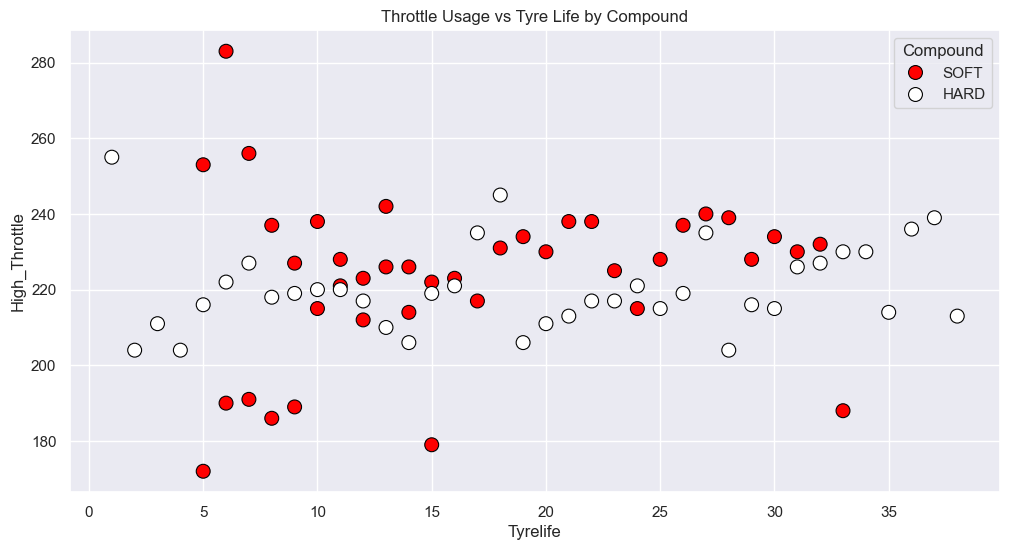

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='darkgrid')
plt.figure(figsize=(12, 6))
scatter=sns.scatterplot(data=df, x='Tyrelife', y='High_Throttle', hue='Compound', palette={'SOFT':'red', 'MEDIUM':'orange', 'HARD':'white'}, edgecolor='black', s=100)
plt.title('Throttle Usage vs Tyre Life by Compound')
plt.show()

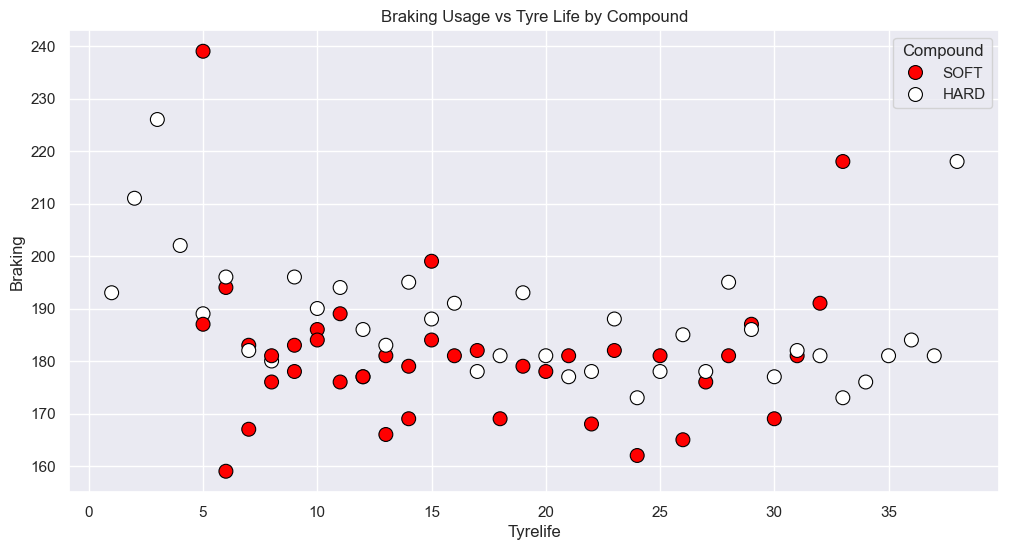

In [5]:
plt.figure(figsize=(12, 6))
scatter=sns.scatterplot(data=df, x='Tyrelife', y='Braking', hue='Compound', palette={'SOFT':'red', 'MEDIUM':'orange', 'HARD':'white'}, edgecolor='black', s=100)
plt.title('Braking Usage vs Tyre Life by Compound')
plt.show()

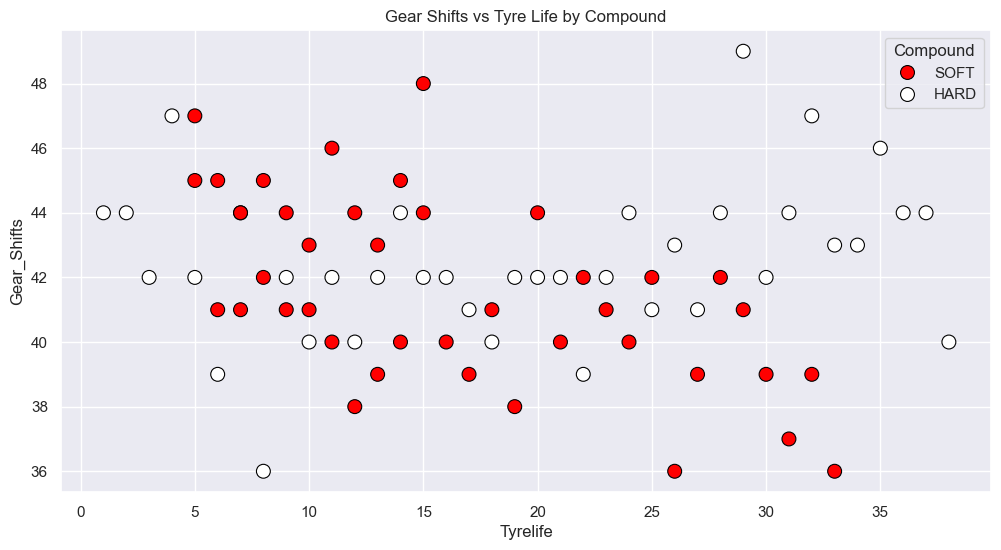

In [6]:
plt.figure(figsize=(12, 6))
scatter=sns.scatterplot(data=df, x='Tyrelife', y='Gear_Shifts', hue='Compound', palette={'SOFT':'red', 'MEDIUM':'orange', 'HARD':'white'}, edgecolor='black', s=100)
plt.title('Gear Shifts vs Tyre Life by Compound')
plt.show()

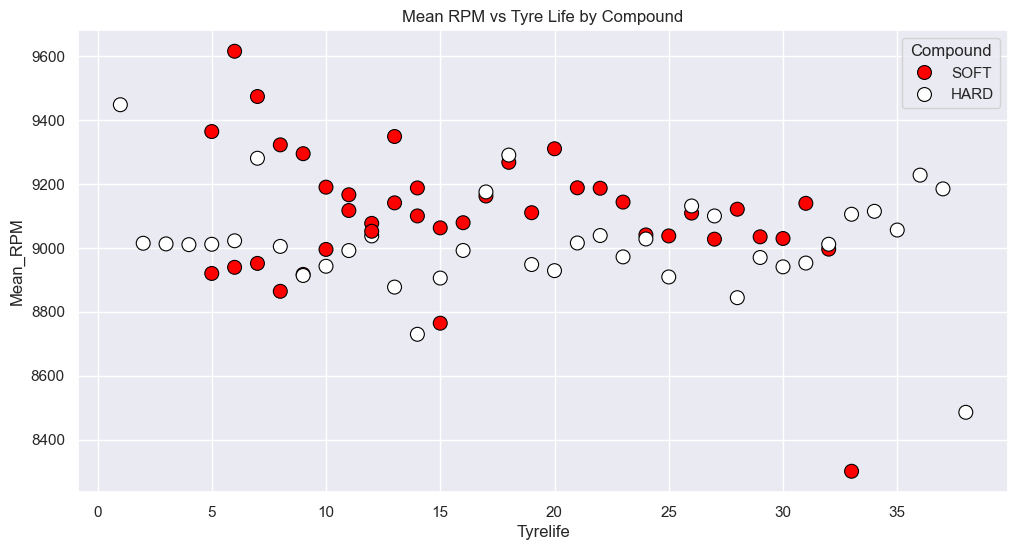

In [7]:
plt.figure(figsize=(12, 6))
scatter=sns.scatterplot(data=df, x='Tyrelife', y='Mean_RPM', hue='Compound', palette={'SOFT':'red', 'MEDIUM':'orange', 'HARD':'white'}, edgecolor='black', s=100)
plt.title('Mean RPM vs Tyre Life by Compound')
plt.show()

It seems that the gearshifts and High_Throttle features show correlation. However, before we exclude the remaining features, let's try to build the following heatmap:


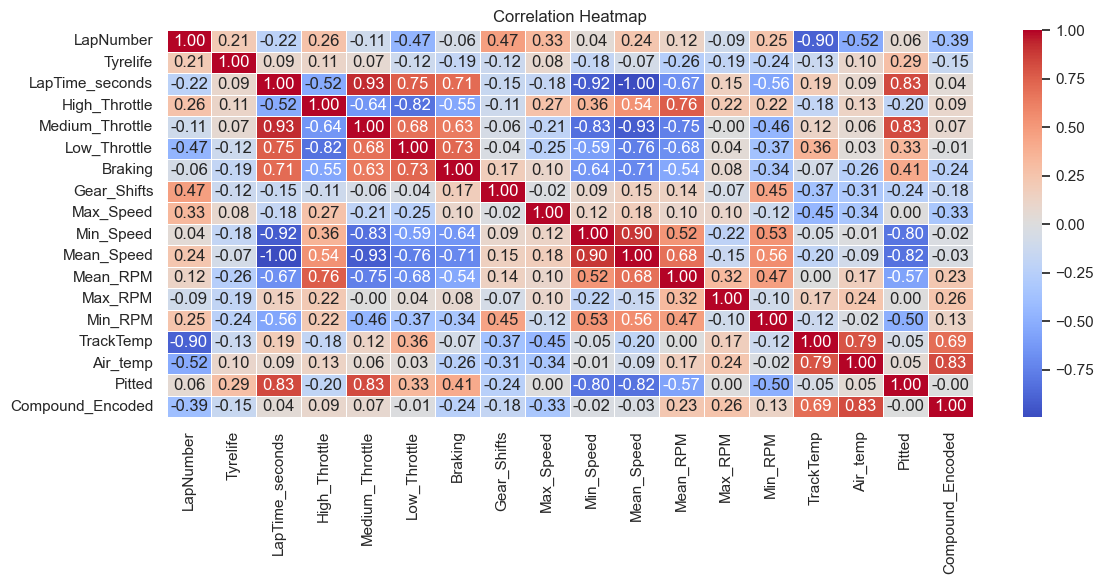

In [8]:
from sklearn.preprocessing import LabelEncoder
df_analysis = df.copy()
if 'Compound' in df_analysis.columns:
    le = LabelEncoder()
    df_analysis['Rainfall'].astype(int)
    df_analysis['Compound_Encoded'] = le.fit_transform(df_analysis['Compound'])
    df_analysis = df_analysis.drop('Compound', axis=1)
    df_numeric = df_analysis.select_dtypes(include=['float64', 'int64', 'int32'])

# Calculating correlations
corr_matrix = df_numeric.corr()


plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Indeed, there don't seem to be any linear dependencies between the features and tire life. However, this is data from one race for a single lap. Let's look at all drivers and all laps:


In [9]:
def get_race_data():
  engineered_data = []
  weather=laps.get_weather_data()
  for i, (index, lap) in enumerate(laps.iterlaps()):
      if pd.isnull(lap['LapTime']):
          continue
      telemetry = lap.get_telemetry()
      if telemetry.empty:
          continue
      #Binning the telemetry data
      high_throttle=(telemetry['Throttle'] >= 90).sum()
      medium_throttle=((telemetry['Throttle'] < 90) & (telemetry['Throttle'] > 40)).sum()
      low_throttle=(telemetry['Throttle'] <= 40).sum()
      braking=(telemetry['Brake']).sum()
      gear_shifts = (telemetry['nGear'].diff().abs() > 0).sum()
      pitted= 0 if pd.isna(lap['PitInTime']) else 1

      # Max and Min values
      max_speed = telemetry['Speed'].max()
      min_speed = telemetry['Speed'].min()
      max_rpm = telemetry['RPM'].max()
      min_rpm = telemetry['RPM'].min()

      #Mean values
      mean_rpm = telemetry['RPM'].mean()
      mean_speed = telemetry['Speed'].mean()

      #Getting the weather data
      track_temp = weather.iloc[i]['TrackTemp']
      air_temp = weather.iloc[i]['AirTemp']
      rainfall = weather.iloc[i]['Rainfall']

      # Append the engineered features to the dictionary
      engineered_data.append({
          'Circuit': session.event['EventName'],
          'LapNumber': lap['LapNumber'],
          'Compound': lap['Compound'],
          'Tyrelife': lap['TyreLife'],
          'LapTime_seconds': lap['LapTime'].total_seconds(),
          'High_Throttle': high_throttle,
          'Medium_Throttle': medium_throttle,
          'Low_Throttle': low_throttle,
          'Braking': braking,
          'Gear_Shifts': gear_shifts,
          'Max_Speed': max_speed,
          'Min_Speed': min_speed,
          'Mean_Speed': mean_speed,
          'Mean_RPM': mean_rpm,
          'Max_RPM': max_rpm,
          'Min_RPM': min_rpm,
          'LapStatus': lap['TrackStatus'],
          'TrackTemp': track_temp,
          'Air_temp': air_temp,
          'Rainfall': rainfall,
          'Pitted': pitted
    })
  df=pd.DataFrame(engineered_data)
  return df
#df=get_race_data() #this will take some time

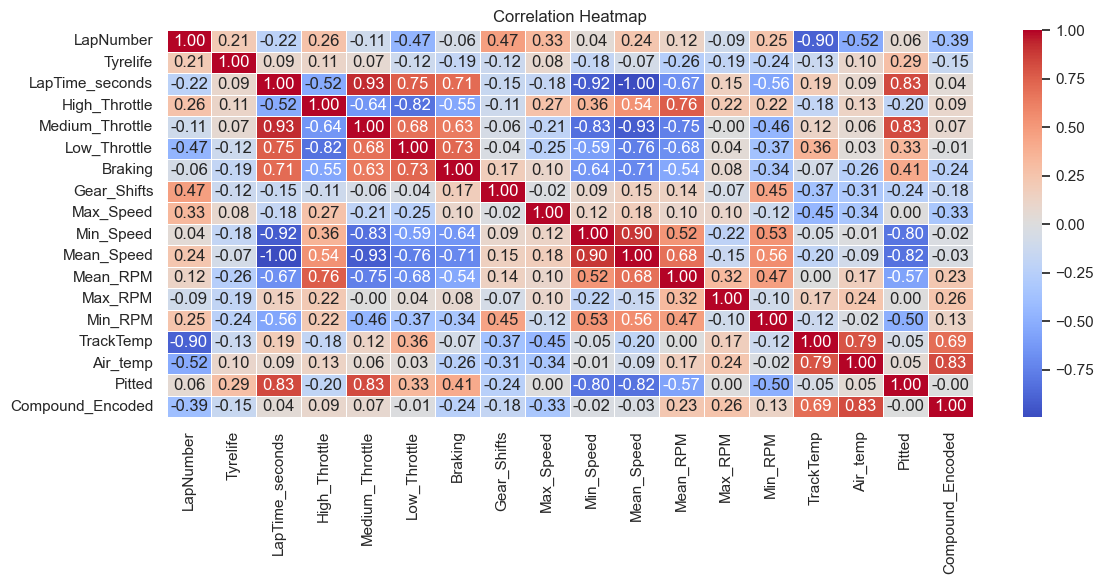

In [10]:
df_analysis = df.copy()
if 'Compound' in df_analysis.columns:
    le = LabelEncoder()
    df_analysis['Rainfall'].astype(int)
    df_analysis['Compound_Encoded'] = le.fit_transform(df_analysis['Compound'])
    df_analysis = df_analysis.drop('Compound', axis=1)
    df_numeric = df_analysis.select_dtypes(include=['float64', 'int64', 'int32'])

# Calculating correlations
corr_matrix = df_numeric.corr()


plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Let's now see what happens on the rest of the circuits/races


In [11]:
# Fetch the 2021 race schedule
schedule = fastf1.get_event_schedule(2021)
races = schedule[schedule['EventFormat'] != 'testing']
races=races['EventName']
display(races)

1            Bahrain Grand Prix
2     Emilia Romagna Grand Prix
3         Portuguese Grand Prix
4            Spanish Grand Prix
5             Monaco Grand Prix
6         Azerbaijan Grand Prix
7             French Grand Prix
8            Styrian Grand Prix
9           Austrian Grand Prix
10           British Grand Prix
11         Hungarian Grand Prix
12           Belgian Grand Prix
13             Dutch Grand Prix
14           Italian Grand Prix
15           Russian Grand Prix
16           Turkish Grand Prix
17     United States Grand Prix
18       Mexico City Grand Prix
19         São Paulo Grand Prix
20             Qatar Grand Prix
21     Saudi Arabian Grand Prix
22         Abu Dhabi Grand Prix
Name: EventName, dtype: object

In [12]:
def get_season_data(year):
  engineered_data=[]
  for race_name in races:
    session = fastf1.get_session(year, race_name, 'R')
    session.load(telemetry=True, weather=True)  # Load telemetry and weather data
    # Get laps data
    laps = session.laps
    df=get_race_data()
    return(df)

In the previous function we forgot to load the driver names, which will help us in categorizing the data. So that we don't have to wait all those hours again, we will fetch them separately and merge them.


In [13]:
def get_stint_drivers():
  lightweight_data = []
  for race_name in races:
      try:
          session = fastf1.get_session(2021, race_name, 'R')
          session.load(telemetry=False, weather=False)

          for index, lap in session.laps.iterlaps():
              if pd.isnull(lap['LapTime']):
                  continue

              lightweight_data.append({
                  'Circuit': race_name,
                  'LapNumber': lap['LapNumber'],
                  'LapTime_seconds': lap['LapTime'].total_seconds(),
                  'Driver': lap['Driver'],
                  'Stint': lap['Stint']
              })
      except Exception:
          continue
  df_drivers = pd.DataFrame(lightweight_data)
  df_final = pd.merge(df, df_drivers,
                      on=['Circuit', 'LapNumber', 'LapTime_seconds'],
                      how='left')
  return df_final
#df_final= get_stint_drivers()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/my_f1_data.parquet'
# Save as a Parquet file
#df.to_parquet(save_path)

In [24]:
load_path = 'C:/Users/User/Documents/AUEB Msc in Business Mathematics/Machine Learning & AI/my_f1_data.parquet'
# Read the dataframe back into memory instantly
df = pd.read_parquet(load_path, engine='fastparquet')

In [36]:
df_final=df.copy()
df_final = df_final.sort_values(by=['Circuit', 'Driver', 'LapNumber']).reset_index(drop=True)
total_laps = df_final.groupby('Circuit')['LapNumber'].transform('max')
df_final['Fuel_Proxy'] = df_final['LapNumber'] / total_laps
df_final = df_final.sort_values(by=['Circuit', 'LapNumber'])
df_final['TrackTemp_Delta'] = df_final['TrackTemp'] - df_final.groupby('Circuit')['TrackTemp'].transform('first')
df_final = df_final.sort_values(by=['Circuit', 'Driver', 'LapNumber']).reset_index(drop=True)
save_path = 'C:/Users/User/Documents/AUEB Msc in Business Mathematics/Machine Learning & AI/my_f1_data(2).parquet'
df_final.to_parquet(save_path, engine='fastparquet')

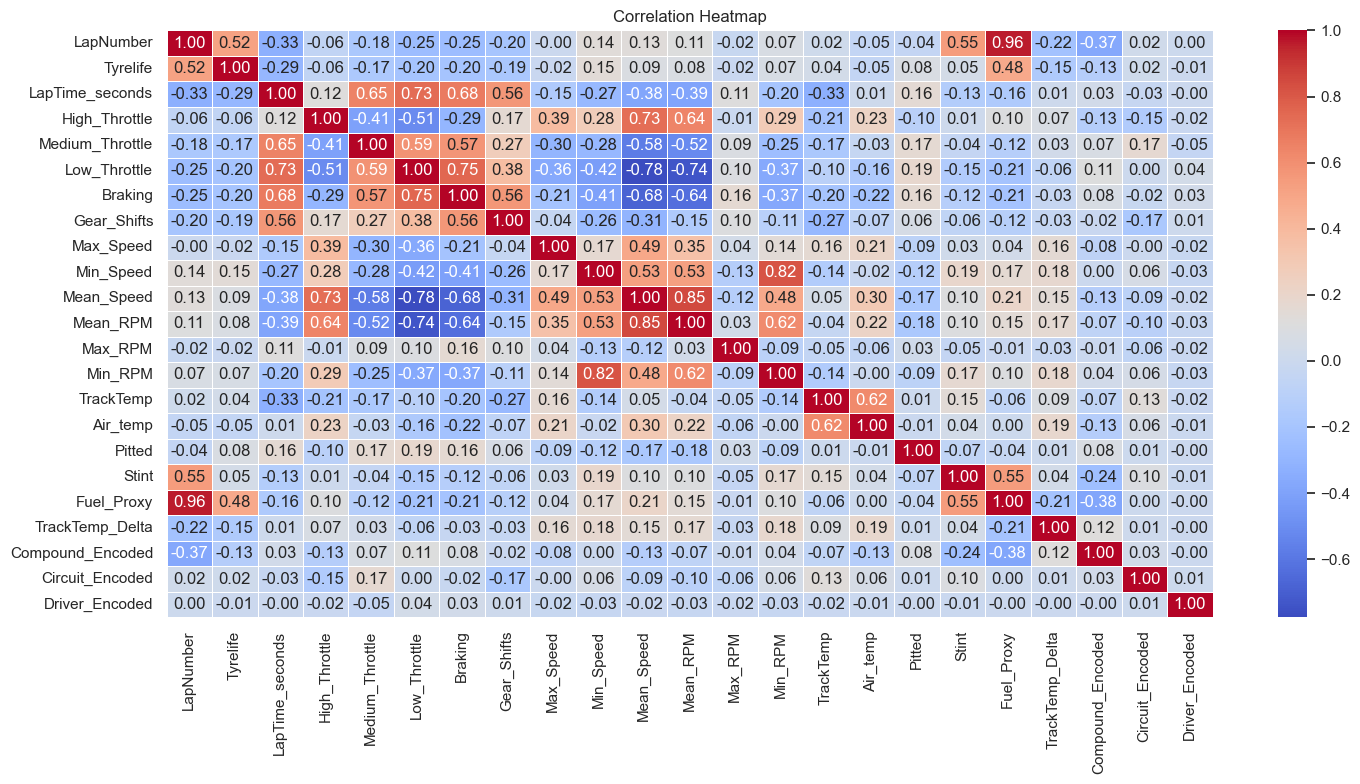

In [26]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
df_analysis = df_final.copy()
if 'Compound' in df_analysis.columns:
    le = LabelEncoder()
    df_analysis['Rainfall'].astype(int)
    df_analysis['Compound_Encoded'] = le.fit_transform(df_analysis['Compound'])
    df_analysis = df_analysis.drop('Compound', axis=1)
    df_analysis['Circuit_Encoded'] = le.fit_transform(df_analysis['Circuit'])
    df_analysis = df_analysis.drop('Circuit', axis=1)
    df_analysis['Driver_Encoded'] = le.fit_transform(df_analysis['Driver'])
    df_analysis = df_analysis.drop('Driver', axis=1)
    df_numeric = df_analysis.select_dtypes(include=['float64', 'int64', 'int32'])

corr_matrix = df_numeric.corr()


plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

 Indeed, there don't seem to be any linear correlations between our features after all. For this reason we need to be careful in building the model to predict wear and the classifier for whether the driver should pit or not.


## Building the Classifier:

Since there are no linear relationships between our features, we will use a binary Random Forest classifier, which will allow us to interpret which features are most important. To evaluate the model we will use the Recall metric.

From the previous heatmap we observe that some features express similar information. So we don't need to use all of them. Another difficulty we may face is the skewness of our data. In F1, drivers usually make 1-2 pit stops per race. So our data will be imbalanced:


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
columns_to_drop = ['Pitted', 'Circuit', 'Driver', 'LapStatus', 'LapNumber']
X = df_final.drop(columns=columns_to_drop, axis=1, errors='ignore')
X = pd.get_dummies(X, columns=['Compound'], drop_first=True)
y = df_final['Pitted']
print(y.describe())
print('Data skewness=', y.skew())



count    23427.000000
mean         0.029581
std          0.169433
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Pitted, dtype: float64
Data skewness= 5.553343764575634


To address this skewness, we can remove data from class 0. We know that pit stops usually don't happen in the first 10 laps of a race. We can also lower the model's threshold.


Αρχικό μέγεθος δεδομένων: 23427 γύροι
After Undersampling: 15136 laps
Class Distribution :
Pitted
0    14443
1      693
Name: count, dtype: int64

--- Classification Report (Custom Threshold 28.000000000000004%) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2889
           1       0.66      0.90      0.76       139

    accuracy                           0.97      3028
   macro avg       0.83      0.94      0.87      3028
weighted avg       0.98      0.97      0.98      3028



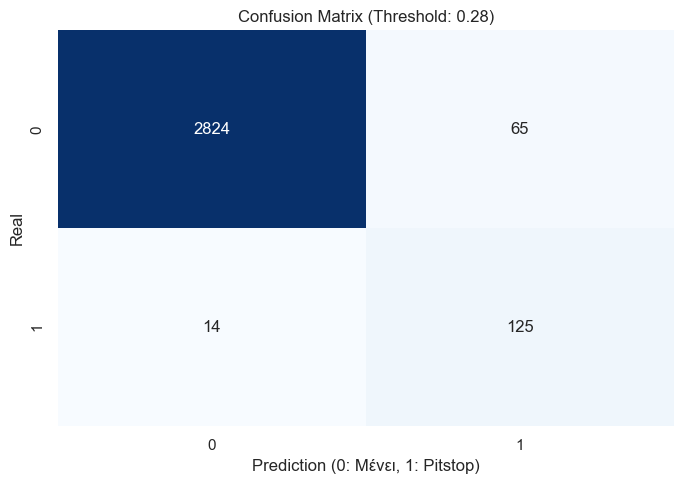

C:\Users\User\AppData\Local\Temp\ipykernel_15964\3247999223.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10], palette='magma')


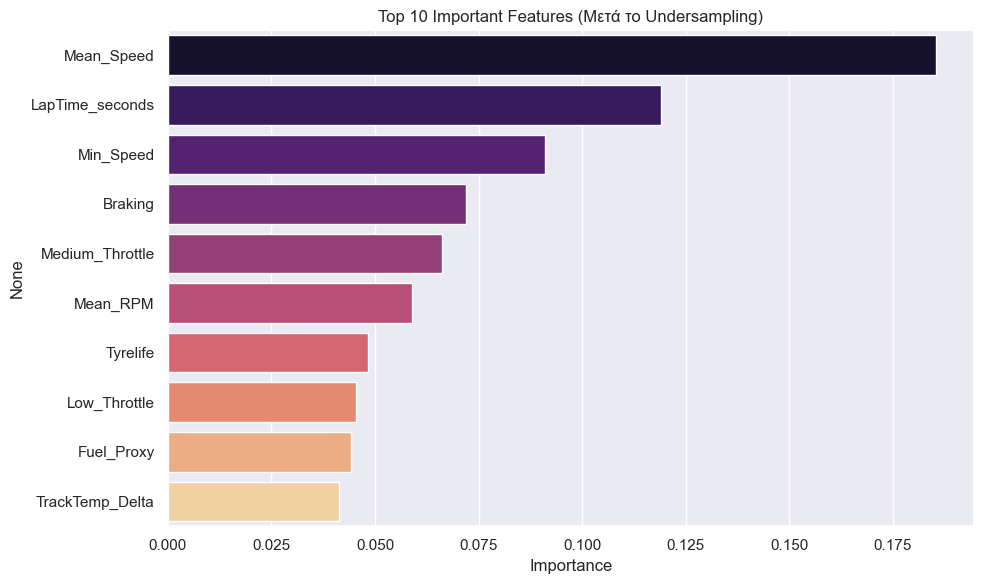

In [29]:
print(f"Initial dataset size: {len(df_final)} laps")
cond_pitted = df_final['Pitted'] == 1
#Filter the initial laps with pit-stops
cond_old_tyres = (df_final['Pitted'] == 0) & (df_final['Tyrelife'] > 10)
df_filtered = df_final[cond_pitted | cond_old_tyres].copy()

print(f"After Undersampling: {len(df_filtered)} laps")
print(f"Class Distribution :\n{df_filtered['Pitted'].value_counts()}")

columns_to_drop = ['Pitted', 'Circuit', 'Driver', 'LapStatus', 'LapNumber']
X = df_filtered.drop(columns=columns_to_drop, axis=1, errors='ignore')
X = pd.get_dummies(X, columns=['Compound'], drop_first=True)
y = df_filtered['Pitted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Training the Random Forest
rf_clf = RandomForestClassifier(n_estimators=200,
                                max_depth=15,
                                class_weight='balanced',
                                random_state=107,
                                n_jobs=-1)
rf_clf.fit(X_train, y_train)

# Threshold Tuning
# Pitstop Class:
y_probs = rf_clf.predict_proba(X_test)[:, 1]
custom_threshold = 0.28
y_pred_custom = (y_probs >= custom_threshold).astype(int)


print(f"\n--- Classification Report (Custom Threshold {custom_threshold*100}%) ---")
print(classification_report(y_test, y_pred_custom))

# Confusion Matrix
plt.figure(figsize=(7, 5))
cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Threshold: {custom_threshold})')
plt.xlabel('Prediction (0: Stays out, 1: Pitstop)')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# 7. Feature Importance
feature_importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10], palette='magma')
plt.title('Top 10 Important Features (After Undersampling)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Model Evaluation:

According to our Classification Report, the model performs satisfactorily, with $accuracy=97\%$. The metric $f1 \ score(0)=0.99$ and $f1 \ score(1)=0.76$ shows that we addressed the class imbalance problem. Most importantly, according to $recall$, we manage to correctly predict 90% of the actual pit stops.

With $90\% \ recall$, the model will catch almost every upcoming anomaly, wear, or performance drop before it turns into a critical failure.

The cost of this safety margin is $66 \% \ precision$. This means that, roughly 3 out of every 10 times the model issues a warning, the situation will actually be normal (False Positive). However, in such demanding environments, it's preferable for engineers to keep an eye on the data for a "false alarm."


## Alternative (Inferior) Model:

Let's try to fit a neural network using time-series data:


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
df_n=df_filtered.copy()
df_n = pd.get_dummies(df_final, columns=['Compound'], drop_first=True)

# Time-Steps
def create_sequences(df, time_steps=3):
    X_seq, y_seq = [], []
    for _, group in df.groupby(['Circuit', 'Driver']):
        group = group.sort_values('LapNumber')

        # Remove the columns that are not features (as done previously)
        features_df = group.drop(columns=['Circuit', 'Driver', 'LapNumber', 'LapStatus', 'Pitted'], errors='ignore')

        # Scale the data (LSTM is much more sensitive to scale than RF)
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features_df)

        targets = group['Pitted'].values

        # Build the "windows"
        for i in range(len(group) - time_steps):
            X_seq.append(features_scaled[i : (i + time_steps)]) # The 3 previous laps
            y_seq.append(targets[i + time_steps])               # The target for the next lap

    return np.array(X_seq), np.array(y_seq)

# Define time steps (how many laps back it looks)
TIME_STEPS = 3

X, y = create_sequences(df_n, time_steps=TIME_STEPS)

print(f"Shape of X for LSTM: {X.shape}")
# You should see something like: (Number of samples, 3, Number of Features)

Διαστάσεις του X για LSTM: (22194, 3, 24)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Compute Class Weights (since Keras doesn't have an automatic 'balanced' option like sklearn)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Building the LSTM
model = Sequential()

# LSTM layer: input_shape = (time_steps, number_of_features)
model.add(LSTM(units=64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3)) # To avoid overfitting

# Output layer (Binary Classification)
model.add(Dense(units=1, activation='sigmoid'))

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict, # Add the weights for the imbalance
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.7029 - loss: 0.5039 - val_accuracy: 0.7748 - val_loss: 0.4495
Epoch 2/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7823 - loss: 0.4192 - val_accuracy: 0.7787 - val_loss: 0.4427
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7903 - loss: 0.3946 - val_accuracy: 0.7782 - val_loss: 0.4311
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8021 - loss: 0.3697 - val_accuracy: 0.8255 - val_loss: 0.3609
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8086 - loss: 0.3608 - val_accuracy: 0.8288 - val_loss: 0.3539
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8116 - loss: 0.3491 - val_accuracy: 0.8170 - val_loss: 0.3710
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8179 - loss: 0.3255 - val_accuracy: 0.8063 - val_loss: 0.3843
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8214 - loss: 0.3211 - val_accuracy:

In [ ]:
# Predict probabilities on the test set
y_probs_lstm = model.predict(X_test).flatten()

# Apply the custom threshold (e.g. 0.29)
custom_threshold = 0.3
y_pred_lstm_custom = (y_probs_lstm >= custom_threshold).astype(int)

print(f"\n--- LSTM Classification Report (Custom Threshold {custom_threshold*100}%) ---")
print(classification_report(y_test, y_pred_lstm_custom))

139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- LSTM Classification Report (Custom Threshold 30.0%) ---
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      4313
           1       0.17      0.60      0.26       126

    accuracy                           0.90      4439
   macro avg       0.58      0.76      0.61      4439
weighted avg       0.96      0.90      0.93      4439



## Wear Prediction Model:

The XGBoost Regression model we will build now will answer a much more complex question: "Based on the wear accumulated so far, how many laps of life remain for this tire set?


In [33]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Calculating Remaining Useful Life (RUL)
df_final['Max_Stint_Laps'] = df_final.groupby(['Circuit', 'Driver', 'Stint'])['Tyrelife'].transform('max')
df_final['Remaining_Laps'] = df_final['Max_Stint_Laps'] - df_final['Tyrelife']
df_final['LapStatus'] = df_final['LapStatus'].astype(int)
Q1 = df_final['LapTime_seconds'].quantile(0.25)
Q3 = df_final['LapTime_seconds'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_clean = df_final[df_final['LapTime_seconds'] <= upper_bound].copy()

# 2. Managing Data Leakage
columns_to_drop = [
    'Pitted',
    'Max_Stint_Laps',
    'Remaining_Laps',
    'Circuit', 'Driver', 'LapNumber'
]

X = df_clean.drop(columns=columns_to_drop, axis=1, errors='ignore')
X = pd.get_dummies(X, columns=['Compound'], drop_first=True)
y = df_clean['Remaining_Laps']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 3. Creating the Model
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1                # use all cores
)

print("Training in progress... This might take a while")
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_pred = np.maximum(y_pred, 0)

Training in progress... This might take a while


## Model Evaluation


To evaluate the model we will rely on the $R^2$ and adjusted $R^2$ metrics. Values of these metrics close to 1 mean that our model makes good predictions. However, if the two values are not close enough to each other, this means our model has overfit. (overfitting)



--- Perfomance Report for the XGBoost Regressor ---
Mean Absolute Error (MAE): 2.46 laps
Root Mean Squared Error (RMSE): 3.93 laps
R-squared (R2): 0.8566
Adjusted R-squared: 0.8559

✅ Small difference (0.0008) between R2 & Adjusted R2.


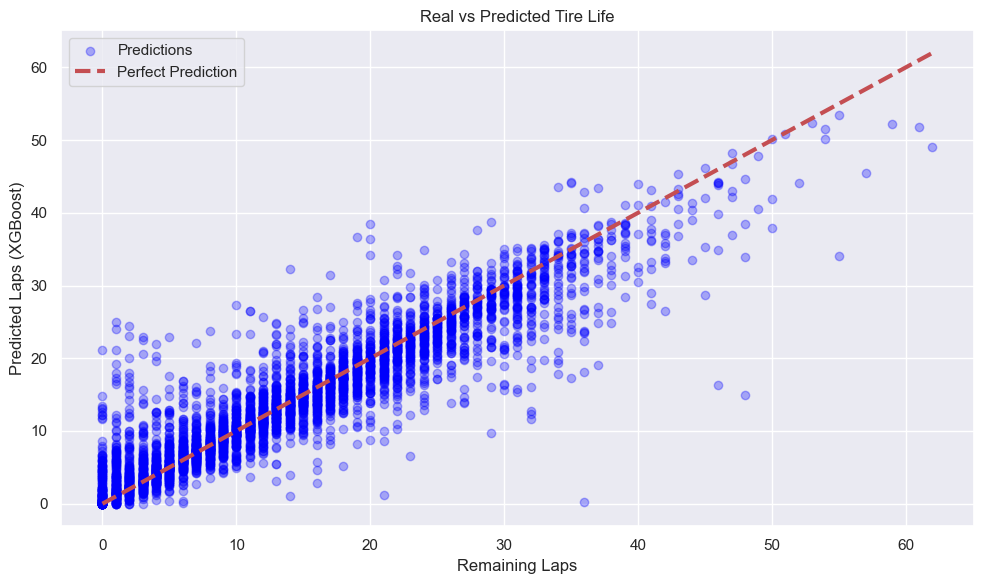

<Figure size 1000x600 with 0 Axes>

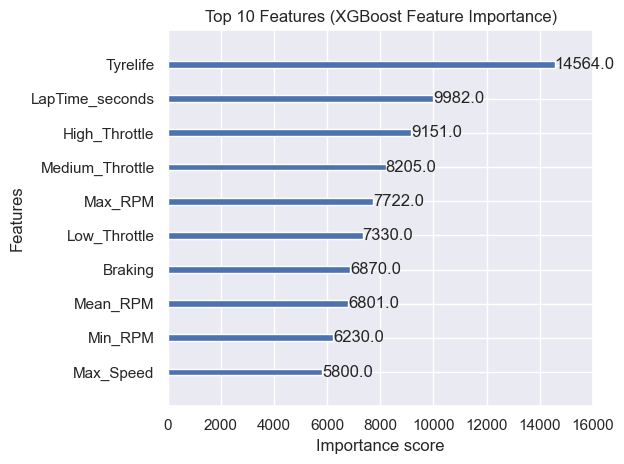

In [34]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n--- Perfomance Report for the XGBoost Regressor ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} laps")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} laps")
print(f"R-squared (R2): {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")

r2_diff = r2 - adj_r2
if r2_diff > 0.05:
    print(f"\n⚠️ Attention: Big Difference ({r2_diff:.4f}) between R2 & Adjusted R2.")
else:
    print(f"\n✅ Small difference ({r2_diff:.4f}) between R2 & Adjusted R2.")


plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Perfect Prediction')
plt.xlabel("Remaining Laps")
plt.ylabel("Predicted Laps (XGBoost)")
plt.title("Real vs Predicted Tire Life")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight',
                    title='Top 10 Features (XGBoost Feature Importance)')
plt.tight_layout()
plt.show()

## Circuit Dashboards Development and Risk Analysis


The purpose of this section is, first, based on telemetry data, to model F1 circuits to a satisfactory degree (a modeling not readily available in any library) and then to analyze their risk from different perspectives. By extracting incident information from marshal messages and with an appropriate choice of weights, areas of elevated risk are displayed on the circuit models using an appropriate color scheme. 

 Also, based on each driver's involvement in incidents, we produce a chart ranking the top 5 drivers who cause accidents or go off the track limits.    


Building reference centerline for British Grand Prix...


core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '16', '77', '31', '11', '24', '63', '10']


core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 44 completed the race distance 00:00.025000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '16', '77', '4', '3', '55', '14', '18', '31', '22', '10', '6

Total classified incident messages: 92
  [sector detection] No sector numbers found in any message - falling back to default of 18.
Located: 71 / 92  (unresolved - no sector or turn number in message: 21)


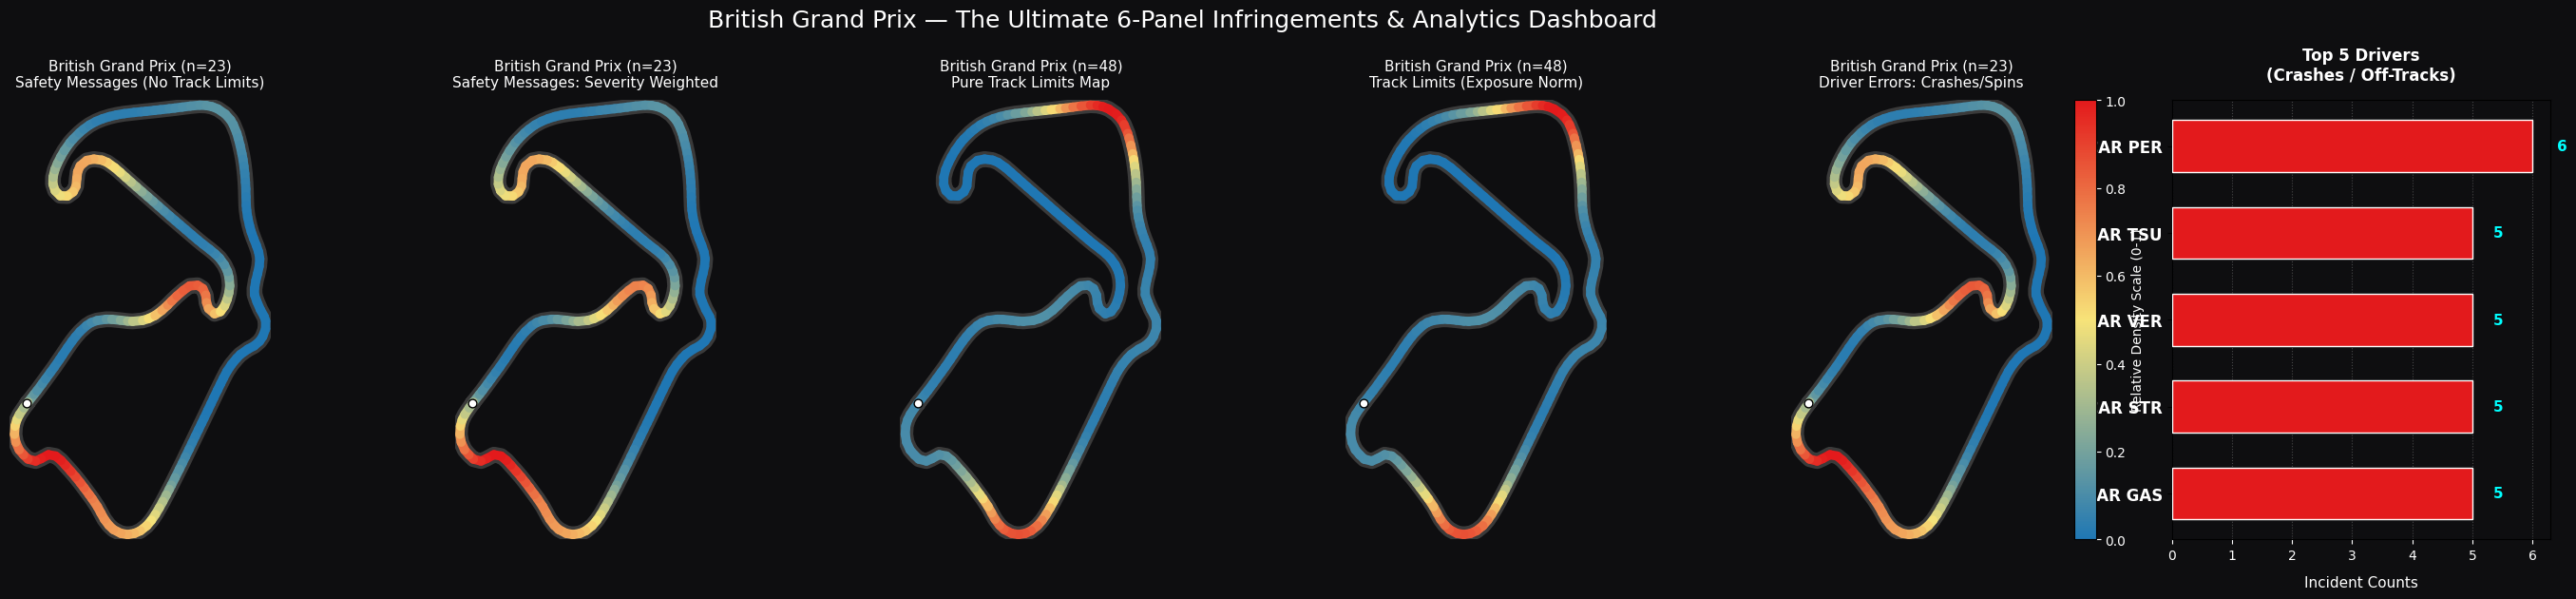


>>> 6-panel Ultimate Dashboard saved to: C:\Users\User\circuit_6panel_output\output\british grand prix_6panel_ultimate_dashboard.png


In [2]:
import fastf1
from fastf1.ergast import Ergast
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
from pathlib import Path
import re

OUTPUT_DIR_NAME = "circuit_6panel_output"
SCRIPT_DIR = Path.home() / OUTPUT_DIR_NAME

OUTPUT_DIR = SCRIPT_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = SCRIPT_DIR / "fastf1_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE_DIR))

# CIRCUIT AND YEARS SELECTION FOR DATA RETRIEVAL
CIRCUIT = "British Grand Prix"
YEARS = list(range(2021, 2025))
N_BINS = 200
SMOOTH_SIGMA = 7
SHOW_PLOTS = True

# WE COUNT THE SECTORS FROM THE RC MESSAGES, BUT IF THERE ARE NO MESSAGES WITH SECTOR,
# WE USE THE DEFAULT (IT IS ACCURATE FOR SOME CIRCUITS,
# BUT NOT FOR ALL - THOUGH THIS DOESN'T MATTER SINCE THERE ARE NO SECTOR MESSAGES FOR THOSE CIRCUITS)
FALLBACK_N_SECTORS = 18

DRIVER_NAMES = {
    "1": "VER","33": "VER", "44": "HAM", "16": "LEC", "4": "NOR", "55": "SAI",
    "11": "PER", "63": "RUS", "10": "GAS", "14": "ALO", "31": "OCO",
    "23": "ALB", "22": "TSU", "18": "STR", "20": "MAG", "27": "HUL",
    "77": "BOT", "24": "ZHO", "47": "MSC", "9": "MAZ", "3": "RIC",
    "5": "VET", "7": "RAI", "21": "DEV", "2": "SAR", "40": "LAW"
}


INCIDENT_KEYWORDS = {
    "TRACK LIMITS": "track_limit",
    "DELETED - LAP TIME": "track_limit",
    "ACCIDENT": "accident",
    "INCIDENT": "accident",
    "SPUN": "accident",
    "COLLISION": "accident",
    "OFF TRACK": "off_track",
    "VIRTUAL SAFETY CAR": "vsc",          # <-- must come before "SAFETY CAR"
    "SAFETY CAR": "safety_car",
    "RED FLAG": "red_flag",
    "YELLOW FLAG": "yellow_flag",
}

NON_INCIDENT_OVERRIDES = ["CHEQUERED FLAG"]

SEVERITY_WEIGHTS = {
    "red_flag": 50.0,
    "accident": 35.0,
    "safety_car": 30.0,
    "vsc": 15.0,
    "off_track": 10.0,
    "yellow_flag": 10.0,
    "track_limit": 5.0
}

SECTOR_RE = re.compile(r"\bSECTOR\s+(\d+)\b")
TURN_RE = re.compile(r"\bTURN\s+(\d+)\b")
DRIVER_NUM_RE = re.compile(r"\b(\d{1,2})\s*\(([A-Z]{3})\)")

# WITH THIS FUNCTION WE RETRIEVE THE FASTEST REFERENCE LAP OF THE CIRCUIT
# SO THAT WE CAN OBTAIN THE REFERENCE CURVE OF THE CIRCUIT WITH THE build_centerline FUNCTION
# IT FOLLOWS THE real racing line, A CLEAN LAP WITHOUT SAFETY CARS, VSC,
# AVOIDS DRIVER ERRORS AND TRACK LIMITS
# A SAFER CHOICE THAN A RANDOM LAP SELECTION

def get_reference_lap(circuit_name: str, year: int):
    session = fastf1.get_session(year, circuit_name, "R")
    session.load(telemetry=True, laps=True, weather=False, messages=False)
    fastest = session.laps.pick_fastest()
    tel = fastest.get_telemetry()
    return session, tel

# Takes irregular position samples (X, Y) at unequal distance intervals,
# and returns uniform position samples at equal distance intervals around the circuit

def build_centerline(tel: pd.DataFrame, n_bins: int = N_BINS):
    x = tel["X"].to_numpy()
    y = tel["Y"].to_numpy()
    dist = tel["Distance"].to_numpy()
    keep = np.concatenate([[True], np.diff(dist) > 0])
    dist, x, y = dist[keep], x[keep], y[keep]
    dist_grid = np.linspace(dist.min(), dist.max(), n_bins)
    # linear interpolation to get the X and Y values at equal distance intervals
    fx = interp1d(dist, x, kind="linear", fill_value="extrapolate")
    fy = interp1d(dist, y, kind="linear", fill_value="extrapolate")
    xy = np.column_stack([fx(dist_grid), fy(dist_grid)])
    return dist_grid, xy

# This is a hierarchical keyword checker applied to text:
# first it excludes known false-positive cases, then it searches in priority order (more specific keywords first)
# to decide what kind of incident the message describes, returning None if it's not something we care about.
def classify_message(msg: str):
    msg_u = msg.upper()
    for override in NON_INCIDENT_OVERRIDES:
        if override in msg_u:
            return None
    for kw, label in INCIDENT_KEYWORDS.items():
        if kw in msg_u:
            return label
    return None

# search the text for a "WORD + number" pattern, extract only the number,
# convert it to int, and return None if nothing is found

def extract_sector(msg: str):
    m = SECTOR_RE.search(msg.upper())
    if m:
        return int(m.group(1))
    return None


def extract_turn(msg: str):
    m = TURN_RE.search(msg.upper())
    if m:
        return int(m.group(1))
    return None


# for each YEAR:
    # find which event matches circuit_name
    # for each matching EVENT:
        # load the session (Race)
        # for each race control MESSAGE in that session:
            # classify the message, if relevant save it

def collect_incidents(circuit_name: str, years: list[int]):
    records = []
    for year in years:
        try:
            schedule = fastf1.get_event_schedule(year)
        except Exception:
            continue
        search_cols = [c for c in ["EventName", "Location", "OfficialEventName", "Country"]
                        if c in schedule.columns]
        mask = False
        for col in search_cols:
            mask = mask | schedule[col].str.contains(circuit_name, case=False, na=False)
        matches = schedule[mask]
        if matches.empty:
            continue

        for _, event in matches.iterrows():
            try:
                session = fastf1.get_session(year, event["EventName"], "R")
                session.load()
            except Exception:
                continue
            rcm = session.race_control_messages
            if rcm is None or rcm.empty:
                continue

            for _, row in rcm.iterrows():
                msg_text = str(row.get("Message", ""))
                label = classify_message(msg_text)
                if label is None:
                    continue
                car_matches = DRIVER_NUM_RE.findall(msg_text)
                car_numbers = [num for num, code in car_matches]  
                records.append({
                    "year": year, "event": event["EventName"], "lap": row.get("Lap", np.nan), "type": label,
                    "sector": extract_sector(msg_text), "turn": extract_turn(msg_text),
                    "car_numbers": car_numbers,
                    "car_number": car_numbers[0] if car_numbers else None,
                    "message": msg_text,
                    "session_obj_ref": (year, event["EventName"]),
                })
    return pd.DataFrame(records)

# FROM THE RC MESSAGES WE DETECT THE NUMBER OF SECTORS USED BY THE CIRCUIT,
# IF THERE ARE NO MESSAGES WITH SECTOR, WE USE THE DEFAULT

def detect_n_sectors(incidents_df: pd.DataFrame) -> int:
    sector_values = incidents_df["sector"].dropna()
    if sector_values.empty:
        print(f"  [sector detection] No sector numbers found in any message - "
              f"falling back to default of {FALLBACK_N_SECTORS}.")
        return FALLBACK_N_SECTORS

    n_detected = int(sector_values.max())
    print(f"  [sector detection] Highest sector number referenced in messages: "
          f"{n_detected} -> using {n_detected} equal-arc-length sectors for this circuit.")
    return n_detected

# This is the function that translates "words" (sector/turn numbers) into "coordinates" (distances along the circuit).
# Two different levels of accuracy:
# Turns: exact position, from actual FastF1 geometry data
# Sectors: only an approximation — we assume all marshal sectors have the same length
# (which is not entirely true in reality, as we discussed earlier),
# but it's the best available estimate without access to exact FIA marshal post boundary data

def build_sector_boundaries(ref_session, dist_grid, n_sectors: int):

    total_dist = float(dist_grid.max())
    turn_distances = {}

    try:
        circuit_info = ref_session.get_circuit_info()
        corners = circuit_info.corners
        if corners is not None and not corners.empty and "Distance" in corners.columns:
            for _, row in corners.iterrows():
                turn_distances[int(row["Number"])] = float(row["Distance"])
    except Exception:
        turn_distances = {}

    bounds = np.linspace(0, total_dist, n_sectors + 1)
    sector_ranges = {i + 1: (bounds[i], bounds[i + 1]) for i in range(n_sectors)}

    return sector_ranges, turn_distances



# TAKES A MESSAGE FROM THE DATAFRAME WITH THE MESSAGES AND DETERMINES ITS EXACT LOCATION ON THE CIRCUIT MAP
# Do you have a turn number AND is it valid?  -> YES: exact position, END
#                                              -> NO: continue
# Do you have a sector number AND is it valid? -> YES: middle of the sector, END
#                                               -> NO: continue
# No position information                     -> None (the incident is dropped from the map)

def locate_incident_on_track(incident_row, sector_ranges, turn_distances, dist_grid):
    turn = incident_row.get("turn")
    sector = incident_row.get("sector")

    if turn is not None and turn in turn_distances:
        return turn_distances[turn]

    if sector is not None and sector in sector_ranges:
        lo, hi = sector_ranges[sector]
        return (lo + hi) / 2.0

    return None

# Counting (histogram): how many (or how "heavy") incidents occurred in each section of the circuit
# Smoothing (gaussian_filter1d): converts sharp, isolated peaks into a smooth, realistic curve
# — correctly handling the closed-loop circuit
# Normalization (dividing by max): converts to a 0-1 scale, ready for coloring

def incidents_to_density(incident_distances: list[float], dist_grid: np.ndarray,
                          weights: list[float] = None, normalize: bool = True):
    n_bins = len(dist_grid)
    bin_edges = np.linspace(dist_grid.min(), dist_grid.max(), n_bins + 1)
    counts, _ = np.histogram(incident_distances, bins=bin_edges, weights=weights)
    density = gaussian_filter1d(counts.astype(float), sigma=SMOOTH_SIGMA, mode="wrap")
    if normalize and density.max() > 0:
        density = density / density.max()
    return density

#
def normalize_by_exposure(raw_density: np.ndarray, unique_sessions: int):
    exposure = np.full(len(raw_density), float(unique_sessions))
    normalized = raw_density / exposure
    if normalized.max() > 0:
        normalized = normalized / normalized.max()
    return normalized


def _draw_risk_map_on_axis(ax, xy: np.ndarray, density: np.ndarray, cmap, circuit_name: str,
                            count: int, subtitle: str = "", mark_start_finish: bool = True):
    points = xy.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    ax.set_facecolor("#0e0e10")
    ax.plot(xy[:, 0], xy[:, 1], color="#3a3a3a", linewidth=12, solid_capstyle="round", zorder=1)
    lc = LineCollection(segments, cmap=cmap, linewidth=7, zorder=2)
    lc.set_array(density[:-1])
    lc.set_capstyle("round")
    lc.set_clim(0, 1)
    ax.add_collection(lc)
    ax.set_xlim(xy[:, 0].min() - 200, xy[:, 0].max() + 200)
    ax.set_ylim(xy[:, 1].min() - 200, xy[:, 1].max() + 200)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"{circuit_name} (n={count})\n{subtitle}", color="white", fontsize=11, pad=10)

    if mark_start_finish:
        _draw_start_finish_marker(ax, xy)


def _draw_start_finish_marker(ax, xy: np.ndarray):
    
    p0 = xy[0]
    p1 = xy[1]
    direction = p1 - p0
    norm = np.linalg.norm(direction)
    if norm > 0:
        direction = direction / norm
    # perpendicular vector (rotate 90 degrees)
    perp = np.array([-direction[1], direction[0]])

    tick_half_length = 60  # world units, tuned to look proportionate at typical circuit scales
    tick_start = p0 - perp * tick_half_length
    tick_end = p0 + perp * tick_half_length

    ax.plot([tick_start[0], tick_end[0]], [tick_start[1], tick_end[1]],
            color="white", linewidth=2.5, zorder=6, solid_capstyle="butt")
    ax.scatter(p0[0], p0[1], s=40, marker="o", facecolor="white", edgecolor="black",
               linewidth=1, zorder=7)


RISK_CMAP = mcolors.LinearSegmentedColormap.from_list("risk", ["#1f77b4", "#f7e379", "#e31a1c"])


def plot_6_panels(xy: np.ndarray, densities: list[np.ndarray], subtitles: list[str], circuit_name: str,
                   counts: list[int], top_violators: pd.Series, out_path: str):
    fig, axes = plt.subplots(1, 6, figsize=(36, 6))
    fig.patch.set_facecolor("#0e0e10")

    for i in range(5):
        _draw_risk_map_on_axis(axes[i], xy, densities[i], RISK_CMAP, circuit_name, counts[i], subtitle=subtitles[i])

    ax_bar = axes[5]
    ax_bar.set_facecolor("#0e0e10")

    if not top_violators.empty:
        names = [DRIVER_NAMES.get(str(num), f"CAR {num}") for num in top_violators.index]
        y_pos = np.arange(len(names))
        bars = ax_bar.barh(y_pos, top_violators.values, color="#e31a1c", edgecolor="white", height=0.6, zorder=3)
        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(names, color="white", fontsize=12, weight="bold")
        ax_bar.invert_yaxis()

        for bar in bars:
            width = bar.get_width()
            ax_bar.text(width + (width * 0.05 + 0.1), bar.get_y() + bar.get_height() / 2, f'{int(width)}',
                        va='center', ha='left', color='cyan', fontweight='bold', fontsize=11)
    else:
        ax_bar.text(0.5, 0.5, "No Driver Data Found", color="gray", ha="center", va="center", fontsize=14)

    ax_bar.set_xlabel("Incident Counts", color="white", fontsize=11, labelpad=10)
    ax_bar.xaxis.set_tick_params(colors="white")
    ax_bar.grid(axis='x', linestyle=':', color='gray', alpha=0.5, zorder=0)
    ax_bar.set_title("Top 5 Drivers\n(Crashes / Off-Tracks)", color="white", fontsize=12, pad=15, weight="bold")

    sm = plt.cm.ScalarMappable(cmap=RISK_CMAP, norm=mcolors.Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, ax=axes[:5], fraction=0.01, pad=0.01, location="right")
    cbar.set_label("Relative Density Scale (0-1)", color="white")
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.get_yticklabels(), color="white")

    fig.suptitle(f"{circuit_name} — The Ultimate 6-Panel Infringements & Analytics Dashboard",
                  color="white", fontsize=18, y=1.04)
    plt.savefig(out_path, dpi=160, facecolor=fig.get_facecolor(), bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


 
def main():
    print(f"Building reference centerline for {CIRCUIT}...")
    ref_session, ref_tel = get_reference_lap(CIRCUIT, YEARS[-1])
    dist_grid, xy = build_centerline(ref_tel, N_BINS)
 
    print(f"Collecting incidents for {CIRCUIT} across {YEARS}...")
    df = collect_incidents(CIRCUIT, YEARS)
    if df.empty:
        print("No incident logs found.")
        return
    print(f"Total classified incident messages: {len(df)}")

    n_sectors = detect_n_sectors(df)
    sector_ranges, turn_distances = build_sector_boundaries(ref_session, dist_grid, n_sectors)
 
    safety_incidents_dist = []
    safety_incidents_weights = []
    limits_distances = []
    errors_distances = []
 
    unresolved_count = 0
    for _, row in df.iterrows():
        d = locate_incident_on_track(row, sector_ranges, turn_distances, dist_grid)
        if d is None:
            unresolved_count += 1
            continue
 
        if row["type"] == "track_limit":
            limits_distances.append(d)
        else:
            safety_incidents_dist.append(d)
            safety_incidents_weights.append(SEVERITY_WEIGHTS.get(row["type"], 1.0))
            if row["type"] in ["accident", "off_track"]:
                errors_distances.append(d)
 
    print(f"Located: {len(df) - unresolved_count} / {len(df)}  "
          f"(unresolved - no sector or turn number in message: {unresolved_count})")
 
    unique_sessions = df["session_obj_ref"].nunique()
 
    d1 = incidents_to_density(safety_incidents_dist, dist_grid)
    d2 = incidents_to_density(safety_incidents_dist, dist_grid, weights=safety_incidents_weights)
    d3 = incidents_to_density(limits_distances, dist_grid)
 
    raw_d4 = incidents_to_density(limits_distances, dist_grid, normalize=False)
    d4 = normalize_by_exposure(raw_d4, unique_sessions)
 
    d5 = incidents_to_density(errors_distances, dist_grid)

    error_drivers_df = df[df["type"].isin(["accident", "off_track"])].copy()
    error_drivers_df = error_drivers_df.explode("car_numbers")
    error_drivers_df = error_drivers_df[error_drivers_df["car_numbers"].notna()]
    error_drivers_df["driver_label"] = error_drivers_df["car_numbers"].apply(
        lambda num: DRIVER_NAMES.get(str(num), f"CAR {num}")
    )
    top_violators = error_drivers_df["driver_label"].value_counts().head(5)
 
    out_path = str(OUTPUT_DIR / f"{CIRCUIT.lower()}_6panel_ultimate_dashboard.png")
 
    plot_6_panels(
        xy,
        densities=[d1, d2, d3, d4, d5],
        subtitles=[
            "Safety Messages (No Track Limits)",
            "Safety Messages: Severity Weighted",
            "Pure Track Limits Map",
            "Track Limits (Exposure Norm)",
            "Driver Errors: Crashes/Spins"
        ],
        circuit_name=CIRCUIT,
        counts=[len(safety_incidents_dist), len(safety_incidents_dist), len(limits_distances),
                len(limits_distances), len(errors_distances)],
        top_violators=top_violators,
        out_path=out_path
    )
    print(f"\n>>> 6-panel Ultimate Dashboard saved to: {out_path}")
 
 
if __name__ == "__main__":
    main()
 

## Conversion to a UI System
We will try to create an interactive AI environment that the user can use to interact with the models above using natural language.  To achieve this, we will make use of Google's APIs. So we will build an agent that can take on the role of a race engineer, use the models, and announce the decisions that need to be made based on their predictions. In addition, we will give it the ability to provide us with information based on the regulations. To do this, we first need to clean the regulations file. Then we need to split the text into small embeddings and store them in a vector database that can be saved on our computer.


In [ ]:
#pip install chromadb pypdf2

In [9]:
import chromadb
from PyPDF2 import PdfReader
import re

def clean_fia_text(text):
    """Cleans the repeated headers and footers from the FIA PDF."""
    if not text:
        return ""
        
    # Remove title and dates
    text = re.sub(r'2021 Formula 1 Sporting Regulations', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Issue \d+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\d{1,2} [A-Z][a-z]+ \d{4}', '', text) # e.g. 11 November 2021
    
    # Remove pagination (e.g. 1 / 88, Page 1 of 88, etc.)
    text = re.sub(r'Page \d+ of \d+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^\d+\s*$', '', text, flags=re.MULTILINE) # Standalone page numbers
    
    # Merge multiple blank lines into one
    text = re.sub(r'\n\s*\n', '\n\n', text)
    
    return text.strip()

def build_fia_database(pdf_path="FIA-2021.pdf"):
    print("[System] Building the FIA regulations database (with text cleaning)...")
    
    reader = PdfReader(pdf_path)
    text_chunks = []
    
    for i, page in enumerate(reader.pages):
        raw_text = page.extract_text()
        cleaned_text = clean_fia_text(raw_text)
        
        # Keep only pages that actually have content (e.g. ignore empty ones)
        if len(cleaned_text) > 50: 
            text_chunks.append({"text": cleaned_text, "metadata": {"page": i + 1}})
            
    DB_PATH = 'C:/Users/User/Documents/AUEB Msc in Business Mathematics/Machine Learning & AI/fia_vectordb'
    chroma_client = chromadb.PersistentClient(path=DB_PATH)
    
    try:
        chroma_client.delete_collection(name="f1_regulations")
    except:
        pass
        
    collection = chroma_client.create_collection(name="f1_regulations")
    
    documents = [chunk["text"] for chunk in text_chunks]
    metadatas = [chunk["metadata"] for chunk in text_chunks]
    ids = [f"page_{i}" for i in range(len(text_chunks))]
    
    collection.add(
        documents=documents,
        metadatas=metadatas,
        ids=ids
    )
    print(f"[System] Success! {len(documents)} regulation pages were read and cleaned.")
    return collection
build_fia_database(pdf_path="FIA-2021.pdf")

[System] Χτίσιμο της βάσης κανονισμών FIA (με καθαρισμό κειμένου)...


C:\Users\User\.cache\chroma\onnx_models\all-MiniLM-L6-v2\onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:24<00:00, 3.42MiB/s]


[System] Επιτυχία! Διαβάστηκαν και καθαρίστηκαν 98 σελίδες κανονισμών.


Collection(name=f1_regulations)

Now that we have built the vector database, we can create an interactive system with the following functionalities:

1. When the system starts, our predictive models will be built and the FIA regulations will be loaded 
2. As soon as the system opens, a menu will be shown to the user so they can choose whether they want to talk to the Race Engineer or simply exit the system
3. Depending on the user's choice, the appropriate Google Gemini API will be called, which will be set up and instructed appropriately so it can use the models we built as tools and interpret them based on the role of the Race Engineer. 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import chromadb
from PyPDF2 import PdfReader
import xgboost as xgb
import google.generativeai as genai
genai.configure(api_key="emter-your-api-key-here")  # Replace with your actual API key
import warnings
warnings.filterwarnings('ignore') # So we don't see annoying warnings in the menu
def load_fia_database():
    DB_PATH = r'C:\Users\User\Documents\AUEB Msc in Business Mathematics\Machine Learning & AI\fia_vectordb'
    print("\n[System] Connecting to the local FIA vector database...")
    try:
        chroma_client = chromadb.PersistentClient(path=DB_PATH)
        collection = chroma_client.get_collection(name="f1_regulations")
        print("[System] The regulations database was loaded successfully!")
        return collection
    except Exception as e:
        print(f"[Error] Local database not found. Details: {e}")
        return None
def initialize_system(file_path):
    print("\n[System] Starting system... Loading data.")
    try:
        df = pd.read_parquet(file_path, engine='fastparquet')
    except Exception as e:
        print(f"[Error] File not found. Check the path. Details: {e}")
        return None, None, None

    print("[System] Training the Random Forest Classifier...")
    cond_pitted = df['Pitted'] == 1
    cond_old_tyres = (df['Pitted'] == 0) & (df['Tyrelife'] > 10)
    df_filtered = df[(cond_pitted | cond_old_tyres)].copy()

    columns_to_drop = ['Pitted', 'Circuit', 'Driver', 'LapStatus', 'LapNumber']
    X = df_filtered.drop(columns=columns_to_drop, axis=1, errors='ignore')
    X = pd.get_dummies(X, columns=['Compound'], drop_first=True)
    y = df_filtered['Pitted']
    rf_feature_cols = X.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=107, n_jobs=-1)
    rf_clf.fit(X_train, y_train)
    
    print("[System] The model was trained successfully!")

    print("[System] Training XGBoost (Remaining Tire Life)...")
    df_xgb = df.copy()
    # Calculating RUL (Remaining Useful Life)
    df_xgb['Max_Stint_Laps'] = df_xgb.groupby(['Circuit', 'Driver', 'Stint'])['Tyrelife'].transform('max')
    df_xgb['Remaining_Laps'] = df_xgb['Max_Stint_Laps'] - df_xgb['Tyrelife']
    df_xgb['LapStatus'] = df_xgb['LapStatus'].astype(int) # XGBoost needs numbers
    
    # Filtering outliers as done previously
    Q3 = df_xgb['LapTime_seconds'].quantile(0.75)
    IQR = Q3 - df_xgb['LapTime_seconds'].quantile(0.25)
    df_xgb_clean = df_xgb[df_xgb['LapTime_seconds'] <= (Q3 + 1.5 * IQR)].copy()
    
    xgb_drop = ['Pitted', 'Max_Stint_Laps', 'Remaining_Laps', 'Circuit', 'Driver', 'LapNumber']
    X_xgb = df_xgb_clean.drop(columns=xgb_drop, errors='ignore')
    X_xgb = pd.get_dummies(X_xgb, columns=['Compound'], drop_first=True)
    y_xgb = df_xgb_clean['Remaining_Laps']
    xgb_features = X_xgb.columns.tolist()
    
    xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.2, max_depth=10, random_state=42)
    xgb_model.fit(X_xgb, y_xgb)
    print("[System] The XGBoost model was trained successfully!")
    print("[System] The system is ready for use.")
    return df, rf_clf, rf_feature_cols, xgb_model, xgb_features

def show_dashboards(df):
    print("\n[Dashboards] Loading visualizations... (Close the chart window to return to the menu)")
    sns.set_theme(style='darkgrid')
    
    # One of your basic charts
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Tyrelife', y='High_Throttle', hue='Compound', 
                    palette={'SOFT':'red', 'MEDIUM':'orange', 'HARD':'gray'}, edgecolor='black', s=50)
    plt.title('Throttle Usage vs Tyre Life by Compound')
    plt.show()

def run_agent(df, rf_model, rf_features, xgb_model, xgb_features, fia_collection):
    print("\n" + "="*50)
    print("🤖 AI RACE ENGINEER (ML Models + FIA RAG)")
    print("="*50)
    print("You can ask me about driver telemetry, the FIA regulations, or ask me to")
    print("show you the risk dashboard for a circuit (e.g. 'Show me the risk dashboard for Monaco').")
    print("Type 'exit' to quit.\n")
    
    # ---------------------------------------------------------
    # [Tool 1]: Telemetry & Machine Learning Models
    # ---------------------------------------------------------
    def analyze_telemetry_and_tires(driver: str, lap_number: float, circuit: str) -> str:
        """
        Analyzes telemetry using Random Forest (pitstop risk)
        and XGBoost (remaining tire life).
        """
        driver = driver.upper().strip()
        circuit = circuit.lower().strip()
        
        lap_data = df[
            (df['Driver'] == driver) & 
            (df['LapNumber'] == lap_number) & 
            (df['Circuit'].str.lower().str.contains(circuit))
        ].copy()
        
        if lap_data.empty:
            return f"No data found for driver {driver}."
            
        lap_row = lap_data.iloc[[0]].copy()
        lap_row['LapStatus'] = lap_row['LapStatus'].astype(int)
        lap_row_encoded = pd.get_dummies(lap_row, columns=['Compound'])
        
        input_rf = pd.DataFrame(0, index=[0], columns=rf_features)
        for col in rf_features:
            if col in lap_row_encoded.columns: input_rf[col] = lap_row_encoded[col].values[0]
                
        input_xgb = pd.DataFrame(0, index=[0], columns=xgb_features)
        for col in xgb_features:
            if col in lap_row_encoded.columns: input_xgb[col] = lap_row_encoded[col].values[0]
        
        prob_rf = rf_model.predict_proba(input_rf)[0][1]
        remaining_laps_xgb = np.maximum(xgb_model.predict(input_xgb)[0], 0)
        current_tyrelife = input_rf['Tyrelife'].values[0]
        matched_circuit = lap_row['Circuit'].values[0]
        
        return (
            f"TELEMETRY REPORT ({matched_circuit}):\n"
            f"- Current tire age: {current_tyrelife} laps.\n"
            f"- XGBoost estimate: {remaining_laps_xgb:.1f} laps of life remaining.\n"
            f"- Random Forest alert: {prob_rf:.1%} probability of immediate pitstop need."
        )

    # ---------------------------------------------------------
    # [Tool 2]: RAG for FIA Regulations
    # ---------------------------------------------------------
    def search_fia_rules(query: str) -> str:
        """
        Use this tool for ANY question related to F1 regulations.
        It can be about in-race strategy, or purely general encyclopedic questions
        (e.g. 'What is DRS?', 'What are the weighing rules?').
        """
        results = fia_collection.query(
            query_texts=[query],
            n_results=4
        )
        
        if not results['documents'][0]:
            return "No relevant regulation was found in the FIA database."
            
        retrieved_text = "\n\n".join(results['documents'][0])
        return f"FIA regulation excerpts:\n{retrieved_text}"

    # ---------------------------------------------------------
    # [Tool 3]: 6-Panel Circuit Risk Dashboard
    # ---------------------------------------------------------
    def show_circuit_risk_dashboard(circuit_name: str, start_year: int = 2021, end_year: int = 2024) -> str:
        """
        Use this ONLY when the user gives the name of a circuit/Grand Prix and asks
        to see/display the risk dashboard (risk dashboard, risk map, 6-panel
        dashboard) based on marshal messages (safety cars, VSC, track limits,
        accidents, off-tracks). It creates and displays the chart based on the code
        already defined (collect_incidents, plot_6_panels, etc.) and returns a short
        text summary of the analysis for you to describe to the user.
        """
        try:
            years = list(range(start_year, end_year + 1))

            ref_session, ref_tel = get_reference_lap(circuit_name, years[-1])
            dist_grid, xy = build_centerline(ref_tel, N_BINS)

            incidents_df = collect_incidents(circuit_name, years)
            if incidents_df.empty:
                return (f"No recorded safety incidents/marshal messages were found "
                        f"for circuit '{circuit_name}' in the years {years[0]}-{years[-1]}.")

            n_sectors = detect_n_sectors(incidents_df)
            sector_ranges, turn_distances = build_sector_boundaries(ref_session, dist_grid, n_sectors)

            safety_incidents_dist, safety_incidents_weights = [], []
            limits_distances, errors_distances = [], []
            unresolved_count = 0
            for _, row in incidents_df.iterrows():
                d = locate_incident_on_track(row, sector_ranges, turn_distances, dist_grid)
                if d is None:
                    unresolved_count += 1
                    continue
                if row["type"] == "track_limit":
                    limits_distances.append(d)
                else:
                    safety_incidents_dist.append(d)
                    safety_incidents_weights.append(SEVERITY_WEIGHTS.get(row["type"], 1.0))
                    if row["type"] in ["accident", "off_track"]:
                        errors_distances.append(d)

            unique_sessions = incidents_df["session_obj_ref"].nunique()

            d1 = incidents_to_density(safety_incidents_dist, dist_grid)
            d2 = incidents_to_density(safety_incidents_dist, dist_grid, weights=safety_incidents_weights)
            d3 = incidents_to_density(limits_distances, dist_grid)
            raw_d4 = incidents_to_density(limits_distances, dist_grid, normalize=False)
            d4 = normalize_by_exposure(raw_d4, unique_sessions)
            d5 = incidents_to_density(errors_distances, dist_grid)

            error_drivers_df = incidents_df[incidents_df["type"].isin(["accident", "off_track"])].copy()
            error_drivers_df = error_drivers_df.explode("car_numbers")
            error_drivers_df = error_drivers_df[error_drivers_df["car_numbers"].notna()]
            error_drivers_df["driver_label"] = error_drivers_df["car_numbers"].apply(
                lambda num: DRIVER_NAMES.get(str(num), f"CAR {num}")
            )
            top_violators = error_drivers_df["driver_label"].value_counts().head(5)

            safe_name = circuit_name.lower().strip().replace(" ", "_")
            out_path = str(OUTPUT_DIR / f"{safe_name}_6panel_ultimate_dashboard.png")

            plot_6_panels(
                xy,
                densities=[d1, d2, d3, d4, d5],
                subtitles=[
                    "Safety Messages (No Track Limits)",
                    "Safety Messages: Severity Weighted",
                    "Pure Track Limits Map",
                    "Track Limits (Exposure Norm)",
                    "Driver Errors: Crashes/Spins"
                ],
                circuit_name=circuit_name,
                counts=[len(safety_incidents_dist), len(safety_incidents_dist), len(limits_distances),
                        len(limits_distances), len(errors_distances)],
                top_violators=top_violators,
                out_path=out_path
            )

            top_summary = (", ".join(f"{name} ({count})" for name, count in top_violators.items())
                           if not top_violators.empty else "no driver data found")

            return (
                f"6-PANEL RISK DASHBOARD ({circuit_name}, {years[0]}-{years[-1]}):\n"
                f"- The dashboard was displayed and saved to: {out_path}\n"
                f"- Detected {n_sectors} sectors on the circuit.\n"
                f"- Total recorded incidents: {len(incidents_df)} "
                f"(located on the track: {len(incidents_df) - unresolved_count}, "
                f"unresolved: {unresolved_count}).\n"
                f"- Safety incidents (safety car/VSC/red-yellow flag etc.): {len(safety_incidents_dist)}.\n"
                f"- Track limit violations: {len(limits_distances)}.\n"
                f"- Driver errors (accidents/off-tracks): {len(errors_distances)}.\n"
                f"- Top drivers in accidents/off-tracks: {top_summary}."
            )
        except Exception as e:
            return f"[Error] Could not generate the risk dashboard for '{circuit_name}': {e}"

    # ---------------------------------------------------------
    # System Instructions (System Instruction)
    # ---------------------------------------------------------
    instruction = (
        "You are the Chief Race Engineer and the ultimate expert on FIA regulations. You have 3 tools:\n"
        "1) analyze_telemetry_and_tires: Use it ONLY when the user asks you to check "
        "a specific driver, lap, and circuit.\n"
        "2) search_fia_rules: Use it to search the official FIA regulations book.\n"
        "3) show_circuit_risk_dashboard: Use it when the user gives the name of a circuit/Grand "
        "Prix and asks to see/display a risk dashboard, risk map, or incident analysis "
        "(safety cars, VSC, track limits, accidents). After calling the tool, describe to the user "
        "in simple terms the summary it returned (how many incidents were found, which types were most common, "
        "which drivers appear most often in accidents/track exits).\n\n"
        "If the user asks a general question (e.g. 'When is an engine change allowed?'), "
        "don't ask them for telemetry. Just use the 2nd tool, read the regulations, "
        "and answer in detail, professionally and in simple terms. If there are reasons to "
        "(e.g. they ask about VSC and a pitstop at the same time) use both tools to give a complete picture."
    )
    
    # ---------------------------------------------------------
    # Model & Chat Initialization
    # ---------------------------------------------------------
    model = genai.GenerativeModel(
        model_name='gemini-2.5-flash',
        tools=[analyze_telemetry_and_tires, search_fia_rules, show_circuit_risk_dashboard],
        system_instruction=instruction
    )
    
    chat = model.start_chat(enable_automatic_function_calling=True)
    
    while True:
        user_input = input("\nYou: ")
        if user_input.lower() == 'exit': break
        try:
            response = chat.send_message(user_input)
            print(f"\nAgent:\n{response.text}")
        except Exception as e:
            print(f"\n[API Error]: {e}")

def main_menu():
    # Your dataset path
    FILE_PATH = 'C:/Users/User/Documents/AUEB Msc in Business Mathematics/Machine Learning & AI/my_f1_data(2).parquet'
    
    # Loading ML Models
    df, rf_model, rf_features, xgb_model, xgb_features = initialize_system(FILE_PATH)
    
    # Loading the local Vector Database
    fia_collection = load_fia_database()
    
    # Check if everything loaded correctly
    if df is None or fia_collection is None:
        print("[System] Terminating due to loading error.")
        return 
        
    while True:
        print("\n" + "🏁"*15)
        print(" F1 STRATEGY & TELEMETRY SYSTEM ")
        print("🏁"*15)
        print("1. Talk to the Race Engineer (Agent)")
        print("0. Exit")
        
        choice = input("\nSelect an action (0-1): ")
        
        if choice == '1':
            # We also pass fia_collection to the agent!
            run_agent(df, rf_model, rf_features, xgb_model, xgb_features, fia_collection)
        elif choice == '0':
            print("Terminating system. Box, box, box!")
            break
        else:
            print("Invalid choice. Please press 1, 2, or 0.")

if __name__ == "__main__":
    main_menu()